In [117]:

#EDA
import pandas as pd
import pingouin as pg
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt


#Machine LEARNIG
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


# otimizacao de Hiperparametros
import optuna


In [118]:
df_segmento = pd.read_csv('./datasets/dataset_segmento_clientes.csv')

## EDA

In [119]:
# Estrutura do dataset
df_segmento.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   atividade_economica     500 non-null    str    
 1   faturamento_mensal      500 non-null    float64
 2   numero_de_funcionarios  500 non-null    int64  
 3   localizacao             500 non-null    str    
 4   idade                   500 non-null    int64  
 5   inovacao                500 non-null    int64  
 6   segmento_de_cliente     500 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 27.5 KB


In [120]:
df_segmento.head(3)

,atividade_economica,faturamento_mensal,numero_de_funcionarios,localizacao,idade,inovacao,segmento_de_cliente
0,Comércio,713109.95,12,Rio de Janeiro,6,1,Bronze
1,Comércio,790714.38,9,São Paulo,15,0,Bronze
2,Comércio,1197239.33,17,São Paulo,4,9,Silver


### Valores unicas de variaveis categoricas

In [121]:
df_segmento.atividade_economica.unique()

<StringArray>
['Comércio', 'Indústria', 'Agronegócio', 'Serviços']
Length: 4, dtype: str

In [122]:
df_segmento.localizacao.unique()

<StringArray>
['Rio de Janeiro', 'São Paulo', 'Vitória', 'Belo Horizonte']
Length: 4, dtype: str

In [123]:
df_segmento.segmento_de_cliente.unique()

<StringArray>
['Bronze', 'Silver', 'Starter', 'Gold']
Length: 4, dtype: str

In [124]:
df_segmento.inovacao.unique()

array([1, 0, 9, 8, 4, 6, 3, 7, 5, 2])

Começamos analisando a distribuição da variável target, que é o segmento de cliente que queremos prever.Observamos que a base está desbalanceada, com a maioria dos registros nos segmentos bronze e silver. Em seguida, utilizamos a biblioteca Plotly para criar gráficos de barras que mostram a distribuição do target de forma visual. Também analisamos a distribuição percentual do target e das variáveis localização, atividade econômica e inovação. Concluímos que há desbalanceamento na base em relação ao target, mas não nas outras variáveis categóricas.

In [125]:
# Distribuição da variavel segmento de cliente ( Target )

contagem_target = df_segmento.value_counts('segmento_de_cliente')
contagem_target

segmento_de_cliente
Silver     260
Bronze     202
Starter     22
Gold        16
Name: count, dtype: int64

In [126]:
# Criar uma lista ordenada do target
list_Segmentos = ['Starter', 'Bronze', 'Silver', 'Gold']


In [127]:
# Distribuição de Variável Target - Contagem

px.bar(contagem_target, color=contagem_target.index,category_orders={'segmento_de_cliente' : list_Segmentos})

In [128]:
# Distribuição de Variável Target - Percentual

percentual_target = contagem_target / len(df_segmento) * 100

In [129]:
px.bar(percentual_target, color=percentual_target.index,category_orders={'segmento_de_cliente' : list_Segmentos})

In [130]:
# Distribuição de Variável Localizacao

percentual_localizacao = df_segmento.value_counts('localizacao') / len(df_segmento) * 100
px.bar(percentual_localizacao, color=percentual_localizacao.index)

In [131]:
# Distribuição de Variável Atividade Economica

percentual_atividade_economica= df_segmento.value_counts('atividade_economica') / len(df_segmento) * 100
px.bar(percentual_atividade_economica, color=percentual_atividade_economica.index)

In [132]:
# Distribuição de Variável Inovacao

percentual_inovacao= df_segmento.value_counts('inovacao') / len(df_segmento) * 100
px.bar(percentual_inovacao, color=percentual_inovacao.index)

### Crosstab Variáveis Qualitativas

exploramos a tabela de contingência entre as variáveis categóricas do nosso dataset. Utilizamos a função crosstab do Pandas para cruzar a quantidade de registros de uma variável categórica com a quantidade de registros do target. Observamos que há um padrão interessante entre a variável Inovação e o segmento das empresas. Nas empresas Gold, por exemplo, não encontramos nenhuma empresa com nível de Inovação menor do que 5, o que indica que para ser considerada Gold, a empresa precisa ter um nível de Inovação mais alto. Já nas empresas Starter, há uma concentração maior nos níveis iniciais de Inovação. Além disso, também analisamos a tabela de contingência entre a localização e o target, e a tabela de contingência entre a atividade econômica e o target. Essas análises nos ajudam a compreender melhor as relações entre as variáveis categóricas e o target. No próximo vídeo, continuaremos nossa análise exploratória de dados.

In [133]:
crosstab_localizacao = pd.crosstab(df_segmento['localizacao'], df_segmento['segmento_de_cliente'], margins=True)[list_Segmentos].reset_index()

tabela_localizacao = ff.create_table(crosstab_localizacao)

# Motrar a Crosstabe

tabela_localizacao.show()

In [134]:
crosstab_atividade = pd.crosstab(df_segmento['atividade_economica'], df_segmento['segmento_de_cliente'], margins=True)[list_Segmentos].reset_index()

tabela_atividade= ff.create_table(crosstab_atividade)

# Motrar a Crosstabe

tabela_atividade.show()

In [135]:
crosstab_inovacao = pd.crosstab(df_segmento['inovacao'], df_segmento['segmento_de_cliente'], margins=True)[list_Segmentos].reset_index()

tabela_inovacao = ff.create_table(crosstab_inovacao)

# Motrar a Crosstabe

tabela_inovacao.show()

### Análise Variáveis Quantitativas

exploramos a relação entre variáveis categóricas e numéricas usando gráficos de boxplot. Primeiro, analisamos a relação entre o segmento de cliente e a idade da empresa. Observamos que, visualmente, não parece haver uma associação forte entre essas duas variáveis. Em seguida, analisamos a relação entre o segmento de cliente e o faturamento mensal. Novamente, não encontramos uma associação direta entre essas variáveis. Concluímos que, graficamente falando, não parece haver uma correlação forte entre as variáveis categóricas e numéricas estudadas. No próximo vídeo, faremos um teste estatístico entre variáveis qualitativas.

In [136]:
# Distribuição Idade da Empresa

px.histogram(df_segmento, x='idade')

In [137]:
# Distribuição Idade da Empresa

px.histogram(df_segmento, x='faturamento_mensal')

In [138]:
# BoxPlot entre Idade e Segmento

px.box(df_segmento, x='segmento_de_cliente', y='idade', color='segmento_de_cliente', category_orders={'segmento_de_cliente' :list_Segmentos})

In [139]:
px.box(df_segmento, x='segmento_de_cliente', y='faturamento_mensal', color='segmento_de_cliente', category_orders={'segmento_de_cliente' : list_Segmentos})

### Correlação Variáveis Qualitativas

concluímos a análise exploratória de dados com um teste estatístico para correlacionar variáveis categóricas com a variável target. Usamos o teste de Qui-Quadrado de Pearson com uma biblioteca diferente para mostrar outras formas de executar o teste. Analisamos a variável "localização" em relação ao "segmento de cliente" e concluímos que as variáveis são independentes. Em seguida, realizamos o mesmo teste para as variáveis "atividade econômica" e "inovação", e também concluímos que são independentes. No entanto, no caso da variável "inovação", encontramos uma correlação significativa, rejeitando a hipótese nula. Com isso, finalizamos a análise exploratória de dados e estamos prontos para treinar nosso modelo.

In [140]:
# Teste de Qui-Quadrado de Pearson

# H0 ( hipotese nula) - as variaveis são independentes
# H1 - as variaveis não são independentes

# Se conseguimos um P-Value inferior a 0.05 recusamos a hipose nula
# Se P-value  maior que 0.05 seguimos com a hipose nula

valor_esperado, valor_obs, estatisticas = pg.chi2_independence(df_segmento, 'segmento_de_cliente', 'localizacao')

c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


In [141]:
# Valor Esperado
# É a frequencia que seria esperada se não houvesse nenhum associacao entre as variáveis.
# É calculado utilizando a distribuição assumida no teste qui-quadrado
 
valor_esperado

localizacao,Belo Horizonte,Rio de Janeiro,São Paulo,Vitória
segmento_de_cliente,,,,
Bronze,44.844,52.924,48.884,55.348
Gold,3.552,4.192,3.872,4.384
Silver,57.720,68.120,62.920,71.240
Starter,4.884,5.764,5.324,6.028


In [142]:
# Valor Observado
# É a frequencia real dos dados coletados

valor_obs

localizacao,Belo Horizonte,Rio de Janeiro,São Paulo,Vitória
segmento_de_cliente,,,,
Bronze,39,62,45,56
Gold,4,3,5,4
Silver,63,60,65,72
Starter,5,6,6,5


In [143]:
# Estatisticas

estatisticas.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,5.19335,9.0,0.81714,0.05884,0.11369
1,cressie-read,0.66667,5.19198,9.0,0.81726,0.05883,0.11367
2,log-likelihood,0.00000,5.19713,9.0,0.81680,0.05886,0.11374
3,freeman-tukey,-0.50000,5.20798,9.0,0.81581,0.05892,0.11390
4,mod-log-likelihood,-1.00000,5.22494,9.0,0.81428,0.05902,0.11414
5,neyman,-2.00000,5.27777,9.0,0.80945,0.05932,0.11490


In [144]:
# P-Value de 0.81714 é maior que 0.05, Seguimos com a hipose nula, as variaveis sao independentes (localizacao e segmento_de_clientes)

In [145]:
valor_esperado, valor_obs, estatisticas = pg.chi2_independence(df_segmento, 'segmento_de_cliente', 'atividade_economica')

c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7198: RuntimeWarning: divide by ze

In [146]:
valor_esperado

atividade_economica,Agronegócio,Comércio,Indústria,Serviços
segmento_de_cliente,,,,
Bronze,47.672,56.156,49.288,48.884
Gold,3.776,4.448,3.904,3.872
Silver,61.360,72.280,63.440,62.920
Starter,5.192,6.116,5.368,5.324


In [147]:
# Valor Observado
# É a frequencia real dos dados coletados

valor_obs

atividade_economica,Agronegócio,Comércio,Indústria,Serviços
segmento_de_cliente,,,,
Bronze,47,56,50,49
Gold,7,5,4,0
Silver,57,75,63,65
Starter,7,3,5,7


In [148]:
# Estatisticas

estatisticas.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,9.96998,9.0,0.35292,0.08153,0.18948
1,cressie-read,0.66667,10.60995,9.0,0.30339,0.08410,0.20060
2,log-likelihood,0.00000,13.54637,9.0,0.13940,0.09503,0.25375
3,freeman-tukey,-0.50000,NaN,9.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.00000,inf,9.0,0.00000,inf,NaN
5,neyman,-2.00000,NaN,9.0,NaN,NaN,NaN


In [149]:
# P-Value de 0.35292 é maior que 0.05, Seguimos com a hipose nula, as variaveis sao independentes (atividade_economica e segmento_de_clientes)

In [150]:
valor_esperado, valor_obs, estatisticas = pg.chi2_independence(df_segmento, 'segmento_de_cliente', 'inovacao')

c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7201: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\scipy\stats\_stats_py.py:7198: RuntimeWarning: divide by ze

In [151]:
# Estatisticas

estatisticas.round(5)

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.00000,164.29399,27.0,0.0,0.33095,0.99850
1,cressie-read,0.66667,165.49946,27.0,0.0,0.33216,0.99861
2,log-likelihood,0.00000,181.48878,27.0,0.0,0.34784,0.99951
3,freeman-tukey,-0.50000,NaN,27.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.00000,inf,27.0,0.0,inf,NaN
5,neyman,-2.00000,NaN,27.0,NaN,NaN,NaN


In [152]:
# As variaveis de Inovacao e Segmento_de_cliente não são independentes. Qui-Quadrado (p-value = 0.0) Elas possuem uma correlação

📍 Localização × Segmento de Cliente

Resultado:

Conclusão: variáveis independentes

Ou seja:

👉 a localização não influencia o segmento de cliente.

📍 Atividade Econômica × Segmento de Cliente

Resultado:

Conclusão: também independentes

👉 o tipo de atividade econômica não tem associação estatística com o segmento.

📍 Inovação × Segmento de Cliente

Rejeitamos a hipótese nula (H0)

As variáveis não são independentes

Existe associação estatisticamente significativa entre elas.

Ou seja, "Inovação" está relacionada ao "Segmento de Cliente".


## Treinamento do Modelo

demos início ao treinamento do nosso modelo de árvore de decisão após a análise exploratória de dados. Primeiro, separamos as variáveis independentes (X) e a variável dependente (Y). Como nosso algoritmo não lida com variáveis categóricas, criamos um pipeline para converter essas variáveis em numéricas usando o OneHotEncoder. Em seguida, criamos um pré-processador com o ColumnTransformer e um pipeline final com o pré-processador e o modelo de árvore de decisão. Utilizamos a validação cruzada estratificada para lidar com o desbalanceamento do dataset. Ao executar o modelo, obtivemos as métricas de acurácia para cada split e calculamos a média. Na próxima aula, exploraremos outras métricas e abordagens para treinar o modelo.

In [153]:
X = df_segmento.drop(columns=['segmento_de_cliente'])
y = df_segmento['segmento_de_cliente']

In [154]:
y.info()

<class 'pandas.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: segmento_de_cliente
Non-Null Count  Dtype
--------------  -----
500 non-null    str  
dtypes: str(1)
memory usage: 4.0 KB


In [155]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   atividade_economica     500 non-null    str    
 1   faturamento_mensal      500 non-null    float64
 2   numero_de_funcionarios  500 non-null    int64  
 3   localizacao             500 non-null    str    
 4   idade                   500 non-null    int64  
 5   inovacao                500 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 23.6 KB


In [156]:
# Pipeline 
# OneHotEncode nas variáveos categóricas
# Treinamento do Modelo

# Lista de varáveis categóricas
categorical_features = ['atividade_economica', 'localizacao']

# Criar um transformer 

categorical_transformer = Pipeline(steps=[
    ('inputer' , SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features)
])

# Pipeline com Pre-Processor e o modelo de Arvore de Decisao
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

### Validação Cruzada

In [157]:
# Treinar o Modelo com Validação cruzada, usando StratifiedKfold, dados as classes estão desbalanceadas

cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=51)

metrics_result = cross_validate(dt_model, X, y, cv=cv_folds, scoring=['accuracy'], return_estimator=True)

In [158]:
metrics_result

{'fit_time': array([0.00500035, 0.00500202, 0.00351238]),
 'score_time': array([0.00263572, 0.00200009, 0.00200009]),
 'estimator': [Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('inputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehot',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['atividade_economica',
                                                     'localizacao'])])),
                  ('classifier', DecisionTreeClassifier())]),
  Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('inputer',
        

In [159]:
# Média da Acurácia, considerando os 3 Splits

metrics_result['test_accuracy'].mean()

np.float64(0.4739917754851743)

### Análise de Métricas

 discutimos sobre métricas de avaliação de modelos de classificação. A métrica escolhida para este módulo foi a acurácia, que mede a proporção de previsões corretas em relação ao total de previsões feitas pelo modelo. No exemplo apresentado, o modelo obteve uma acurácia de aproximadamente 47%, o que indica que acertou menos da metade das previsões. Além da acurácia, existem outras métricas que serão abordadas nos próximos módulos. Para avaliar o desempenho do modelo, utilizamos o método cross-val-predict para fazer previsões e o método classification_report para gerar um relatório com diversas métricas, como precision, recall e f1-score. Também mostramos a matriz de confusão, que permite identificar onde o modelo errou e acertou mais. Essas informações são importantes para tomar decisões sobre o modelo e sua aplicação. No próximo vídeo, vamos abordar a sintonia de hiperparâmetros e a visualização da árvore de decisão.

In [160]:
# Acurácia
# Total de previsões corretas / total de previsões


In [161]:
# # Fazendo  predições com cross validation

y_pred = cross_val_predict(dt_model, X, y, cv=cv_folds)

In [162]:
# Avaliar o desempenho do modelo

classification_report_str = classification_report(y, y_pred)

print('Relatorio de Classificacao: \n ',classification_report_str)

Relatorio de Classificacao: 
                precision    recall  f1-score   support

      Bronze       0.41      0.36      0.38       202
        Gold       0.00      0.00      0.00        16
      Silver       0.51      0.63      0.57       260
     Starter       0.00      0.00      0.00        22

    accuracy                           0.47       500
   macro avg       0.23      0.25      0.24       500
weighted avg       0.43      0.47      0.45       500



c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luan.albuquerque\.virtualenvs\IA-Decision-Tree-3GBdEavc\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

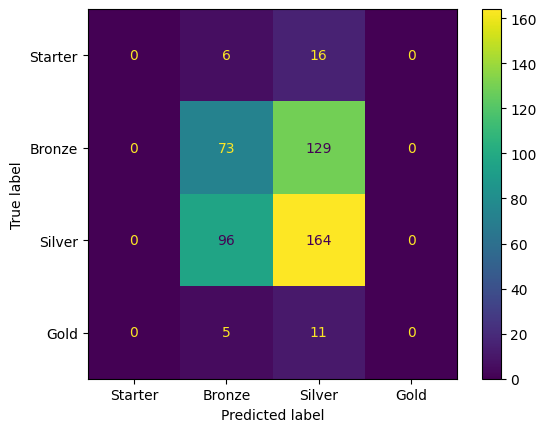

In [163]:
# Mostrar Matriz de Confusão

confusion_matriz_Modelo = confusion_matrix(y, y_pred, labels=list_Segmentos)
disp = ConfusionMatrixDisplay(confusion_matriz_Modelo, display_labels=list_Segmentos)

disp.plot()

### Turning de Hiperparâmetros

Nesta aula, discutimos a importância de ajustar os hiperparâmetros de um modelo de machine learning para melhorar sua performance. Exploramos a biblioteca Optuna, que automatiza o processo de busca pelos melhores hiperparâmetros. Focamos em dois hiperparâmetros específicos: MinSamplesLeaf e MaxDepth. Discutimos como esses hiperparâmetros afetam o desempenho do modelo e como definir um espaço de busca adequado para eles. Demonstramos como usar o Optuna para executar experimentos e encontrar os melhores hiperparâmetros. Ao final, mostramos o melhor resultado obtido e os hiperparâmetros correspondentes. O objetivo dessa abordagem é maximizar a acurácia do modelo.

In [199]:
# Ajustar hiperparâmetros do Modelo usando Optuna
# min_samples_leaf = Mínimo de instância requerido para formar uma folha (nó  terminal)
# mas_deo\pth = Profundidade máxima da árvore


def decisiontree_optuna(trial):
    
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_depth = trial.suggest_int('max_depth', 2, 8)

    dt_model.set_params(classifier__min_samples_leaf=min_samples_leaf)
    dt_model.set_params(classifier__max_depth=max_depth)

    scores = cross_val_score(dt_model, X, y, cv=cv_folds, scoring='accuracy')

    return scores.mean()



In [200]:
#Executar a automação de experimentos

estudo_decisiontree = optuna.create_study(direction='maximize')
estudo_decisiontree.optimize(decisiontree_optuna, n_trials=200)

[I 2026-03-20 23:15:32,299] A new study created in memory with name: no-name-75eed873-11e9-40c3-addb-977dbd6894d4
[I 2026-03-20 23:15:32,326] Trial 0 finished with value: 0.4739917754851743 and parameters: {'min_samples_leaf': 10, 'max_depth': 7}. Best is trial 0 with value: 0.4739917754851743.
[I 2026-03-20 23:15:32,346] Trial 1 finished with value: 0.4740518962075848 and parameters: {'min_samples_leaf': 9, 'max_depth': 2}. Best is trial 1 with value: 0.4740518962075848.
[I 2026-03-20 23:15:32,367] Trial 2 finished with value: 0.4740518962075848 and parameters: {'min_samples_leaf': 13, 'max_depth': 2}. Best is trial 1 with value: 0.4740518962075848.
[I 2026-03-20 23:15:32,392] Trial 3 finished with value: 0.4679797032441142 and parameters: {'min_samples_leaf': 20, 'max_depth': 6}. Best is trial 1 with value: 0.4740518962075848.
[I 2026-03-20 23:15:32,414] Trial 4 finished with value: 0.4739917754851743 and parameters: {'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 1 with value

In [201]:
#Mostra melhor resultado e melhor conjunto de hiperparametros

print(f'Melhor acuracia: {estudo_decisiontree.best_value}' )
print(f'Melhor parametros:{ estudo_decisiontree.best_params}' )


Melhor acuracia: 0.4740518962075848
Melhor parametros:{'min_samples_leaf': 9, 'max_depth': 2}


Neste vídeo, aprendemos como visualizar uma árvore de decisão gerada por um algoritmo. Para isso, fizemos algumas transformações nos dados para prepará-los para a visualização. Criamos uma cópia do conjunto de dados e realizamos uma codificação das variáveis categóricas para que pudéssemos representá-las na árvore. Em seguida, treinamos o modelo com os hiperparâmetros ideais e utilizamos o método Plot Tree para visualizar a árvore resultante. Interpretamos os valores presentes no gráfico, como as perguntas feitas pelo modelo e as classes atribuídas a cada ramo da árvore. Observamos que o modelo teve dificuldade em distinguir entre as classes Silver e Bronze. Concluímos ressaltando a importância da interpretabilidade dos modelos e encerramos o vídeo.

### Visualizar Árvore

In [181]:
# Preparar o Conjunto de dados para treinar e conseguir visualizar a árvore

X_train_tree = X.copy()
X_train_tree['localizacao_label'] = X_train_tree.localizacao.astype('category').cat.codes
X_train_tree['atividade_economica_label'] = X_train_tree.atividade_economica.astype('category').cat.codes

X_train_tree.drop(columns=['atividade_economica', 'localizacao'], axis=['columns'], inplace=True)

X_train_tree.rename(columns={'atividade_economica_label' : 'atividade_economica', 'localizacao_label': 'localizacao'}, inplace=True)

X_train_tree.head(10)

,faturamento_mensal,numero_de_funcionarios,idade,inovacao,localizacao,atividade_economica
0,713109.95,12,6,1,1,1
1,790714.38,9,15,0,2,1
2,1197239.33,17,4,9,2,1
3,449185.78,15,6,0,2,2
4,1006373.16,15,15,8,2,0
5,1629562.41,16,11,4,1,3
6,771179.95,13,0,1,3,3
7,707837.61,16,10,6,2,3
8,888983.66,17,10,1,0,1
9,1098512.64,13,9,3,1,2


In [205]:
# Treinar o modelo com o conjunto de hiperparametros ideal

clf_decisiontree = DecisionTreeClassifier(min_samples_leaf=estudo_decisiontree.best_params['min_samples_leaf'],
                                           max_depth=estudo_decisiontree.best_params['max_depth'])

y_train_tree = y.copy()

y_train_tree = clf_decisiontree.fit(X_train_tree, y_train_tree)

[Text(0.5, 0.8333333333333334, 'inovacao <= 2.5\ngini = 0.563\nsamples = 500\nvalue = [202, 16, 260, 22]\nclass = Silver'),
 Text(0.25, 0.5, 'faturamento_mensal <= 425959.422\ngini = 0.482\nsamples = 165\nvalue = [112, 0, 35, 18]\nclass = Starter'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.26\nsamples = 13\nvalue = [2, 0, 0, 11]\nclass = Gold'),
 Text(0.375, 0.16666666666666666, 'gini = 0.421\nsamples = 152\nvalue = [110, 0, 35, 7]\nclass = Starter'),
 Text(0.75, 0.5, 'faturamento_mensal <= 549601.438\ngini = 0.474\nsamples = 335\nvalue = [90.0, 16.0, 225.0, 4.0]\nclass = Silver'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.459\nsamples = 37\nvalue = [26, 0, 7, 4]\nclass = Starter'),
 Text(0.875, 0.16666666666666666, 'gini = 0.416\nsamples = 298\nvalue = [64.0, 16.0, 218.0, 0.0]\nclass = Silver')]

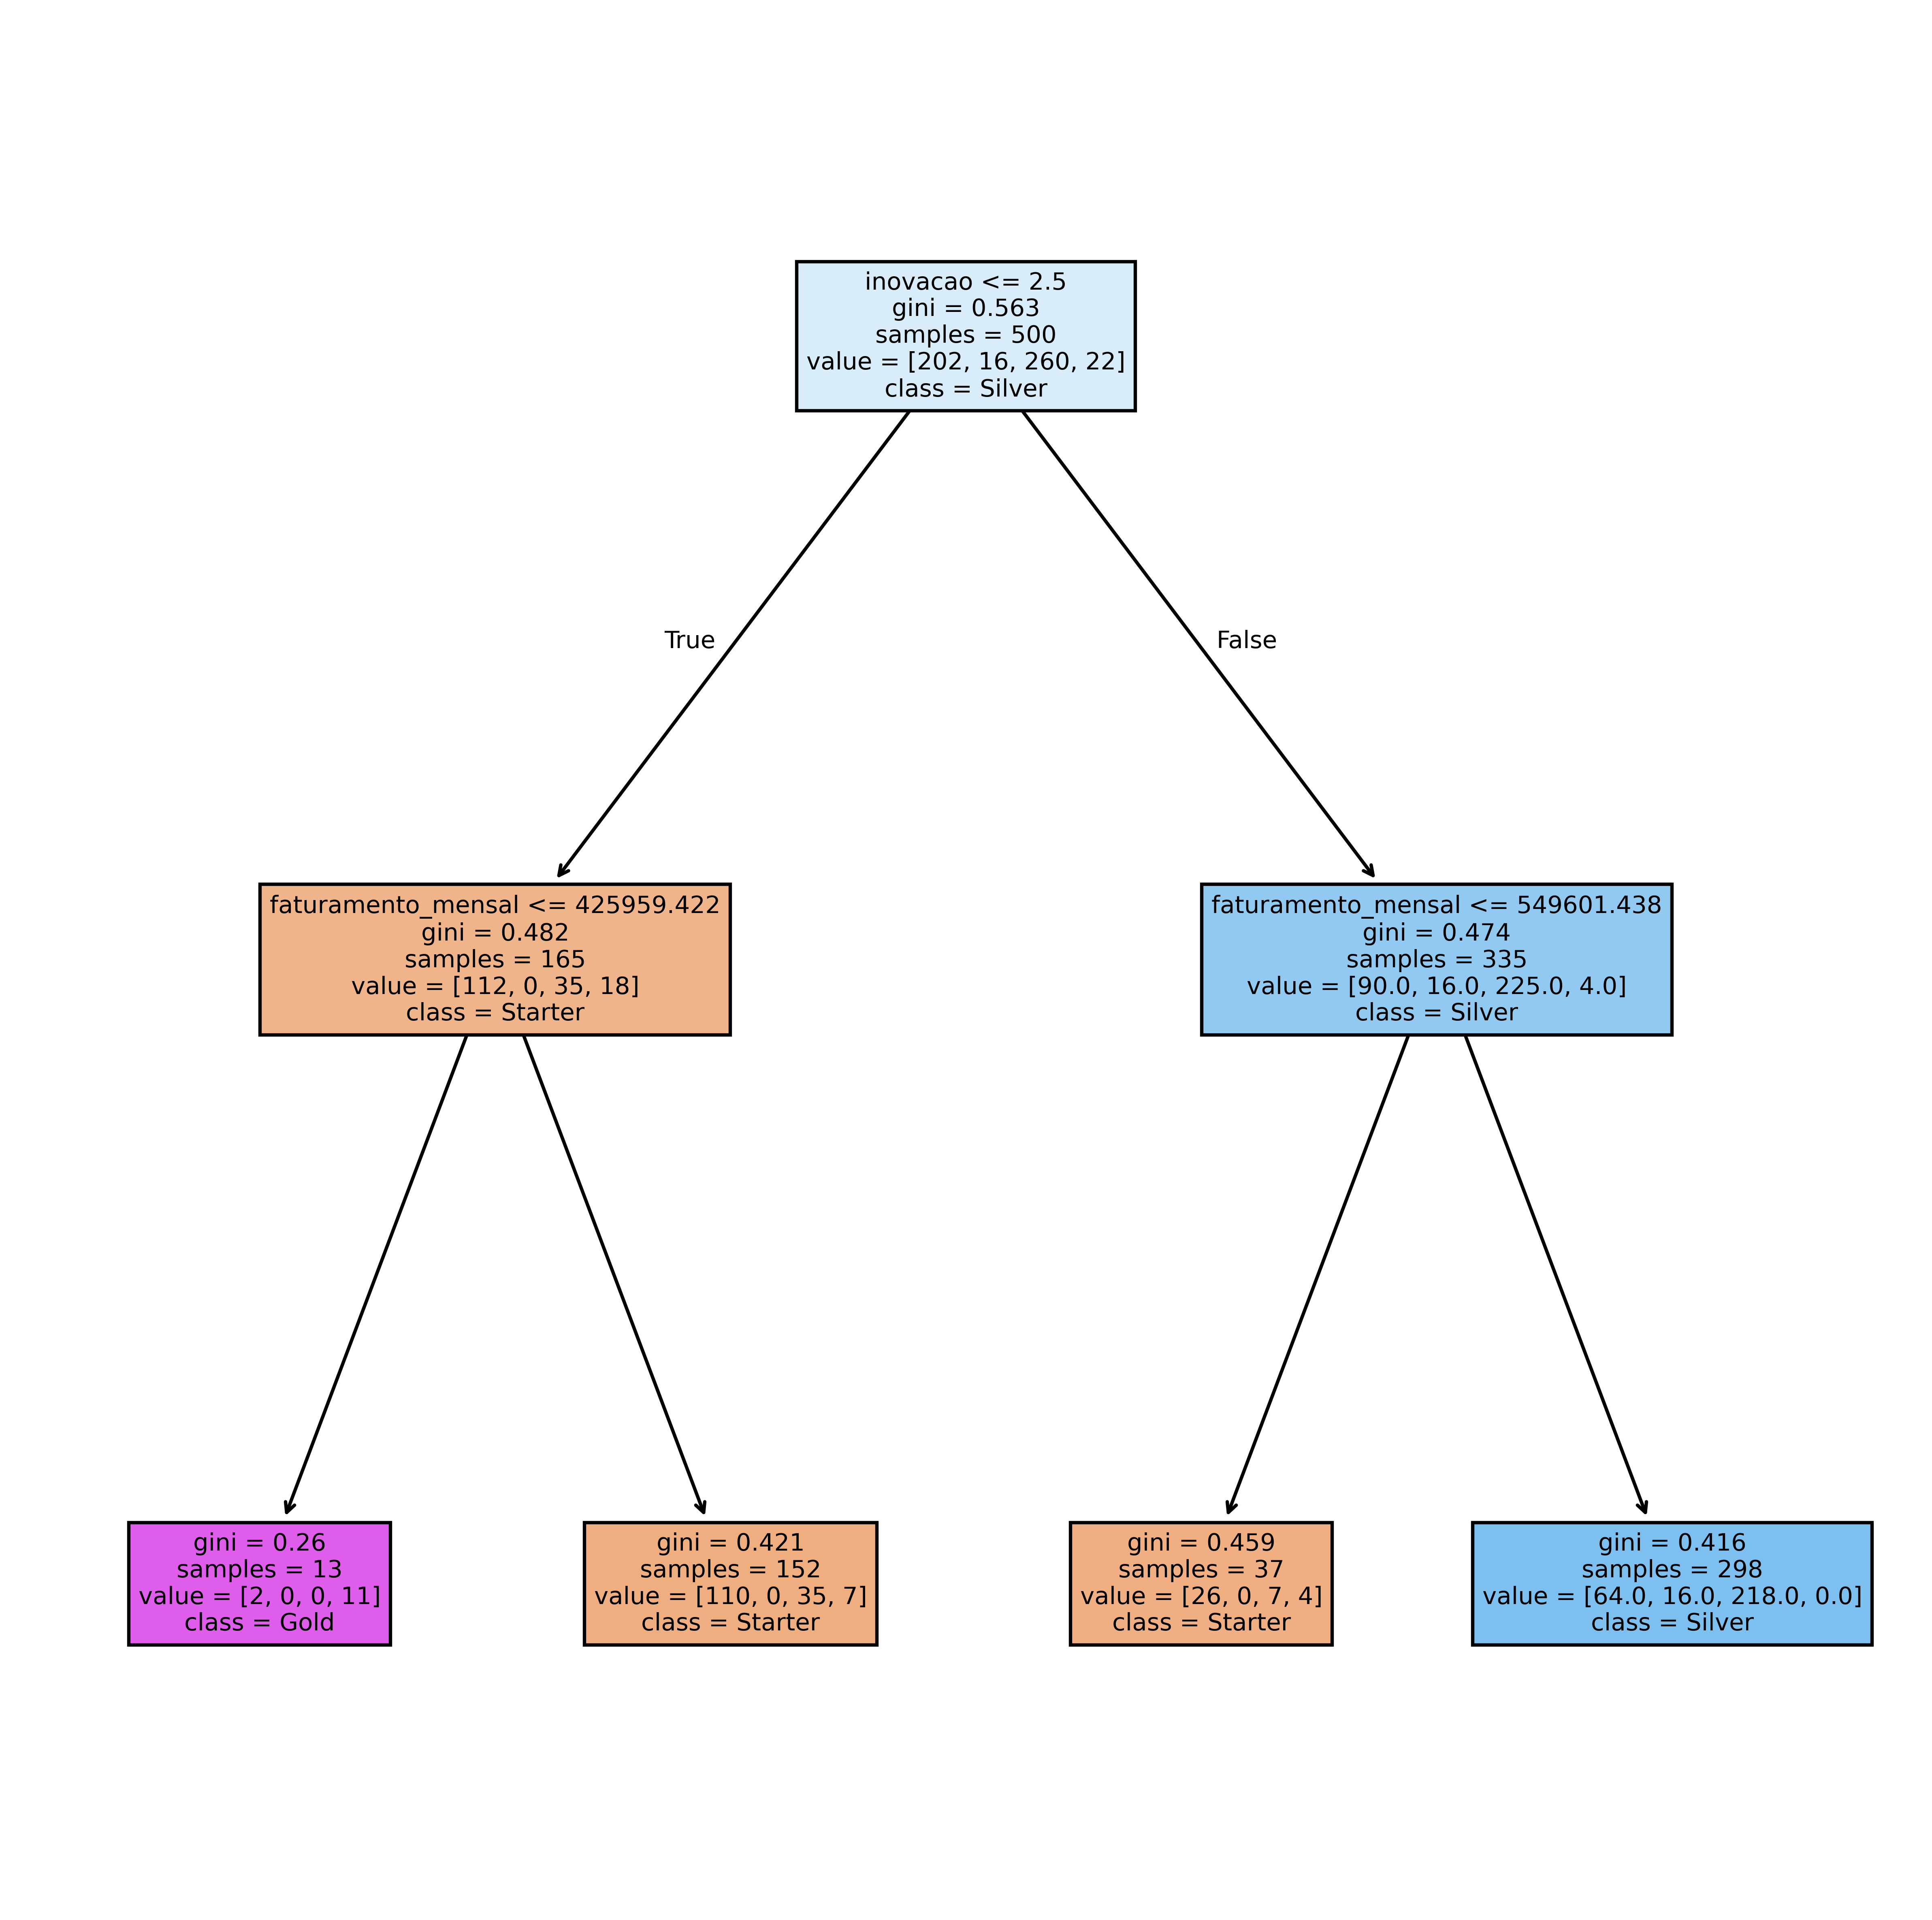

In [209]:
# Visualizar Arvore de Decisao com PLot Tree

fix, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,10), dpi=600)

plot_tree(clf_decisiontree,
          feature_names=X_train_tree.columns.to_numpy(),
          class_names=list_Segmentos,
          filled=True)

Nesta aula, aprendemos como salvar um modelo de machine learning para uso posterior. Utilizamos a biblioteca JobLib para criar um pipeline com o modelo tunado, ou seja, com os melhores hiperparâmetros. O pipeline consiste em dois steps: o preprocessor, que realiza as transformações das colunas, e o classifier, que é o classificador em si. Após treinar o modelo, utilizamos a função joblib.dump() para salvar o modelo em um arquivo. Com isso, podemos utilizar esse modelo para fazer predições em batch.

### Salvar Modelo

In [213]:
import joblib

# Cirar um pipline "tunato"

dt_model_tunado = Pipeline(steps=
[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier( min_samples_leaf=estudo_decisiontree.best_params['min_samples_leaf'],
                                           max_depth=estudo_decisiontree.best_params['max_depth']))
])

In [214]:
dt_model_tunado.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [216]:
# Salvar Model
joblib.dump(dt_model_tunado, 'modelo_classificao_decision_tree.pkl')

['modelo_classificao_decision_tree.pkl']

Nesta aula, criamos um DataFrame chamado "Empresas" e definimos a função "predict". Essa função recebe um arquivo como entrada e lê esse arquivo para um DataFrame. Em seguida, fazemos a predição usando o modelo carregado anteriormente e criamos um novo DataFrame chamado "Segmentos" com a classificação resultante. Depois, concatenamos os DataFrames de entrada e saída em um novo DataFrame chamado "Predições" e salvamos esse DataFrame como um arquivo CSV. Por fim, usamos o gradio para criar uma interface visual simples que permite ao usuário fazer o upload de um arquivo, executar a função de predição e fazer o download do arquivo resultante. Essa abordagem é útil para lidar com predições em lote, onde recebemos um arquivo com informações e retornamos um arquivo com as informações e a classificação feita pelo modelo.

In [235]:
modelo = joblib.load('./modelo_classificao_decision_tree.pkl')

### Entregar Modelo como App de Predicao Batch ( por arquivo)

In [219]:
import gradio as gr

In [239]:
def predict(arquivo):

    df_empresas = pd.read_csv(arquivo.name)
    
    y_pred = modelo.predict(df_empresas)

    df_segmentos = pd.DataFrame(y_pred, columns=['segmento_de_cliente'])
    df_predicoes = pd.concat([df_empresas, df_segmentos], axis=1)

    df_predicoes.to_csv('./predicoes.csv', index=False)

    return './predicoes.csv'


demo = gr.Interface(
    predict,
    gr.File(file_types=['.csv']),
    "file"
)

In [240]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
